In [ ]:
using Lux, SciMLSensitivity, Optimization, OptimizationOptimisers, Statistics, Random, ComponentArrays, StaticArrays, Zygote, DifferentialEquations




In [26]:
using Base.Threads
println("Currently using $(Threads.nthreads()) threads")

Currently using 28 threads


In [27]:
using LinearAlgebra

# Set BLAS to use your physical cores (Try 10 first, then 20)
BLAS.set_num_threads(10) 
println("BLAS using $(BLAS.get_num_threads()) threads")

BLAS using 10 threads


In [28]:
using CSV, DataFrames

# Define the file path (using forward slashes for Windows compatibility)
file_path = "c:/Users/ADMIN/Downloads/Neural_Spiking_Dynamics/notebooks/1_data_generation/single_spike_noisy_data.csv"

# Read the CSV into a DataFrame called HH_data
HH_data = CSV.read(file_path, DataFrame)

# Now you can run your existing code:
# df_ordered = HH_data[:, [:timestamp, :V, :n, :m, :h]]


Row,timestamp,V,m,n,h
,Float64,Float64,Float64,Float64,Float64
1,0.0,-65.0,0.05,0.6,0.32
2,0.01,-64.8362,0.0502886,0.599784,0.320059
3,0.02,-64.7979,0.050523,0.599864,0.32014
4,0.03,-64.7164,0.0507588,0.599507,0.319583
5,0.04,-64.6138,0.0510483,0.599157,0.319957
6,0.05,-64.5264,0.0511813,0.599141,0.320164
7,0.06,-64.4333,0.0514343,0.599205,0.320036
8,0.07,-64.3753,0.0516107,0.59923,0.319876
9,0.08,-64.3345,0.0520745,0.599158,0.319637


In [29]:

df_ordered = DataFrame(
    timestamp = HH_data.timestamp,
    V = HH_data.V,
    n = HH_data.h,
    m = HH_data.m,
    h = HH_data.n
)
# Display the first few rows to verify
first(df_ordered, 5)

Row,timestamp,V,n,m,h
,Float64,Float64,Float64,Float64,Float64
1,0.0,-65.0,0.32,0.05,0.6
2,0.01,-64.8362,0.320059,0.0502886,0.599784
3,0.02,-64.7979,0.32014,0.050523,0.599864
4,0.03,-64.7164,0.319583,0.0507588,0.599507
5,0.04,-64.6138,0.319957,0.0510483,0.599157


In [30]:
end_timestamp = df_ordered.timestamp[end]
df_ordered.timestamp[end]


14.68

In [31]:
# 2. Move your training data to the GPU
t_train = Float32.(df_ordered.timestamp)
z_train = Float32.(Matrix(df_ordered[:, [:V, :n, :m, :h]])') 

4×1469 Matrix{Float32}:
 -65.0   -64.8363     -64.7979    …  -57.3823    -57.4143    -57.4497
   0.32    0.320059     0.32014        0.395085    0.395061    0.39517
   0.05    0.0502886    0.050523       0.112056    0.112553    0.112654
   0.6     0.599784     0.599864       0.453623    0.453502    0.453245

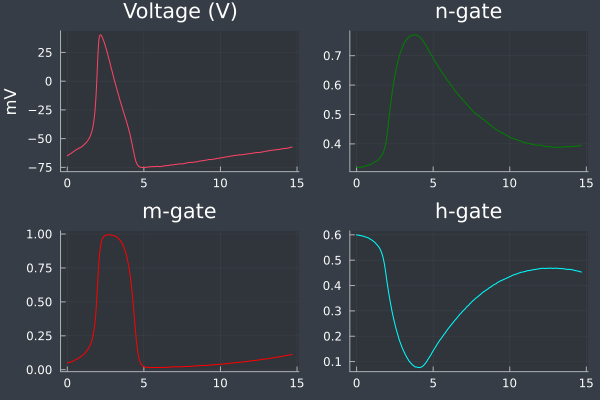

In [32]:
using Plots
theme(:dark)
# Create 4 subplots in a 2x2 grid
p1 = plot(df_ordered.timestamp, df_ordered.V, title="Voltage (V)", ylabel="mV")
p2 = plot(df_ordered.timestamp, df_ordered.n, title="n-gate", color=:green)
p3 = plot(df_ordered.timestamp, df_ordered.m, title="m-gate", color=:red)
p4 = plot(df_ordered.timestamp, df_ordered.h, title="h-gate", color=:cyan)

plot(p1, p2, p3, p4, layout=(2, 2), legend=false)


In [33]:
rng = Random.default_rng()


TaskLocalRNG()

### Scale_Factor

In [34]:
function calculate_scale_factors(z_train,t_train)
    # det the time step (dt)
    dt = diff(t_train) # ( t_i+1 - t_i )
    dz = diff(z_train, dims=2)
    # calculate derivatives ( Finite difference)
    derivatives = dz ./ dt'
    ## result is a 4-element vector: [s_v, s_n, s_m, s_h]
    s_factors = std(derivatives, dims=2)
    
    return s_factors # [s_v, s_n, s_m, s_h]
end


calculate_scale_factors (generic function with 1 method)

In [35]:
# Use 64 hidden units and add time as an input (5 inputs total)
# Added Lux.LayerNorm to stabilize the forward pass
nn = Lux.Chain(
    Lux.Dense(5 => 64, Lux.tanh),
    Lux.LayerNorm(64),
    Lux.Dense(64 => 64, Lux.tanh),
    Lux.LayerNorm(64),
    Lux.Dense(64 => 4)            
)

# 3. Move your model states and parameters to the GPU
rng = Random.default_rng()
ps, st = Lux.setup(rng, nn)
ps = ps 
st = st 

# This is the line that defines the missing variable!
p_initial = ComponentArray(ps) 

scale_factors = calculate_scale_factors(z_train, t_train)


4×1 Matrix{Float32}:
 40.362667
  0.101838976
  0.36055735
  0.103662506

In [36]:
function hh_equations(u)
    # Extract the 4 state variables from the input matrix
    # Using u[1:1, :] instead of u[1, :] keeps them as 2D arrays (1 x N matrices),
    # which makes the math operations play nicely with Zygote (the automatic differentiator)
    V = u[1:1, :] 
    n = u[2:2, :]
    m = u[3:3, :]
    h = u[4:4, :]
    
    # 1. Physical Parameters 
    I_ext = 10.0f0
    g_Na  = 120.0f0
    g_K   = 36.0f0
    g_L   = 0.3f0
    E_Na  = 50.0f0
    E_K   = -77.0f0
    E_L   = -54.4f0
    C_m   = 1.0f0

    # 2. Compute Ionic Currents using array broadcasting (.)
    I_Na = g_Na .* (m.^3) .* h .* (V .- E_Na)
    I_K  = g_K .* (n.^4) .* (V .- E_K)
    I_L  = g_L .* (V .- E_L)
    
    # 3. Compute True Derivatives
    # Membrane potential (dV/dt)
    dV = (I_ext .- I_Na .- I_K .- I_L) ./ C_m
    
    # Gating variables (dn/dt, dm/dt, dh/dt)
    # Using the alpha and beta rate functions you defined earlier
    dn = α_n.(V) .* (1.0f0 .- n) .- β_n.(V) .* n
    dm = α_m.(V) .* (1.0f0 .- m) .- β_m.(V) .* m
    dh = α_h.(V) .* (1.0f0 .- h) .- β_h.(V) .* h
    
    # 4. Stack the derivatives back into a 4 x N matrix
    return vcat(dV, dn, dm, dh)
end


hh_equations (generic function with 1 method)

### Loss Function ( total_loss = loss_data + Physics_loss)


In [37]:
function pyhysics_loss(nn, state_data, t_data, p, scale_factors)
    # 1. Reshape time from a 1D vector (N,) to a 2D matrix (1, N) for concatenation
    t_mat = reshape(t_data, 1, :)
    
    # 2. Concatenate state variables and time: (4, N) + (1, N) -> (5, N)
    input_5d = vcat(state_data, t_mat)
    
    # 3. Forward pass with the full 5D input
    pred_derivs, _ = nn(input_5d, p, st)

    # 4. Calculate true HH derivatives (it only needs the 4 state variables)
    true_dervis = hh_equations(state_data)

    # 5. Compute scale-aware residual
    residuals = (pred_derivs .- true_dervis) ./ scale_factors
    
    # mean(abs2, ...) is numerically safer and more Zygote-friendly than mean(...^2)
    return mean(abs2, residuals)
end


pyhysics_loss (generic function with 1 method)

### The Training Synergy

In [38]:
# Float32 Rate Functions
α_m(V) = 0.1f0 .* (V .+ 40.0f0) ./ (1.0f0 .- exp.(-(V .+ 40.0f0) ./ 10.0f0))
β_m(V) = 4.0f0 .* exp.(-(V .+ 65.0f0) ./ 18.0f0)
α_h(V) = 0.07f0 .* exp.(-(V .+ 65.0f0) ./ 20.0f0)
β_h(V) = 1.0f0 ./ (1.0f0 .+ exp.(-(V .+ 35.0f0) ./ 10.0f0))
α_n(V) = 0.01f0 .* (V .+ 55.0f0) ./ (1.0f0 .- exp.(-(V .+ 55.0f0) ./ 10.0f0))
β_n(V) = 0.125f0 .* exp.(-(V .+ 65.0f0) ./ 80.0f0)
   
function neural_dynamics(u, p, t)
    # 1. Reshape u into a 4x1 matrix 
    input_state = reshape(u, :, 1)
    
    # 2. Add time 't' as the 5th input feature.
    # We use fill(t, 1, 1) to make it a 1x1 matrix and convert it to the correct type
    t_mat = typeof(input_state)(fill(t, 1, 1))
    input_5d = vcat(input_state, t_mat)
    
    # 3. Evaluate on GPU (or CPU depending on where your arrays live)
    dudt_2d, _ = nn(input_5d, p, st) 
    
    return vec(dudt_2d)
end

tspan = (0.0f0,  Float32.(end_timestamp))
# 4. Move your Initial Conditions to the GPU
u0_gpu = Float32[-65.0f0, 0.05f0, 0.6f0, 0.32f0]
node_prob = ODEProblem(neural_dynamics, u0_gpu, tspan, p_initial)

p = Float32[
    10.0,  # External current
    120.0, # Max Sodium conductance
    36.0,  # Max Potassium conductance
    0.3,   # Leak conductance
    50.0,  # Sodium reversal potential
    -77.0, # Potassium reversal potential
    -54.4, # Leak reversal potential
    1.0    # Membrane capacitance
]


node_prob = ODEProblem(neural_dynamics, u0_gpu, tspan, p_initial)


ODEProblem with uType Vector{Float32} and tType Float32. In-place: false
Non-trivial mass matrix: false
timespan: (0.0f0, 14.68f0)
u0: 4-element Vector{Float32}:
 -65.0
   0.05
   0.6
   0.32

In [39]:
function predict(θ)
    new_prob = remake(node_prob, p=θ)
    
    # Swapped Heun() for Tsit5() - the gold standard for Neural ODEs
    # Added autojacvec=ZygoteVJP() to make the backward pass much faster
    return solve(new_prob, Heun(), 
                 saveat=t_train, 
                 reltol=1e-5, abstol=1e-5,
                 sensealg=QuadratureAdjoint(autojacvec=ZygoteVJP()))
end

predict (generic function with 1 method)

### Defining the loss function


In [40]:
function total_loss(θ, _)
    sol = predict(θ) 
    
    if !SciMLBase.successful_retcode(sol)
        return Inf32 
    end
    
    # FIX: Use Array(sol) instead of sol[:, :]. 
    # SciMLSensitivity has a built-in adjoint (gradient rule) specifically for Array()
    pred_data = Array(sol) 
    
    # Everything happens on the GPU now
    loss_data = mean(abs2, pred_data .- z_train)

    # FIX: We now pass t_train to pyhysics_loss so it has the 5th time dimension
    loss_phys = pyhysics_loss(nn, z_train, t_train, θ, scale_factors)

    λ = 1.5f0
    return loss_data + λ * loss_phys
end


total_loss (generic function with 1 method)

In [41]:
# 1. Create an empty array to track the loss
loss_history = Float32[]
# 2. Define the callback function to save the loss at each step
callback_fn = function (θ, loss_val)
    push!(loss_history, loss_val)
    
    # Optional: Print the loss every 10 iterations so you aren't staring at a blank screen
    if length(loss_history) % 10 == 0
        println("Iteration: $(length(loss_history)) | Loss: $(loss_val)")
    end
    
    return false # False means "do not halt the optimization"
end

#23 (generic function with 1 method)

In [ ]:
# optimization 
optf  = OptimizationFunction(total_loss, Optimization.AutoZygote())
optprob = OptimizationProblem(optf, p_initial)

# 3. Run the optimization, passing our callback_fn
println("Starting Training...")
result = solve(optprob, Adam(0.001), maxiters = 5000, callback = callback_fn)
println("Training Complete!")

Starting Training...
Iteration: 10 | Loss: 229.3921
Iteration: 20 | Loss: 209.51736
Iteration: 30 | Loss: 210.0787
Iteration: 40 | Loss: 205.02087
Iteration: 50 | Loss: 201.13533
Iteration: 60 | Loss: 196.89676
Iteration: 70 | Loss: 191.9218
Iteration: 80 | Loss: 186.8839
Iteration: 90 | Loss: 181.02531
Iteration: 100 | Loss: 175.72313
Iteration: 110 | Loss: 170.23466
Iteration: 120 | Loss: 164.09647
Iteration: 130 | Loss: 157.41975
Iteration: 140 | Loss: 155.82617
Iteration: 150 | Loss: 147.825
Iteration: 160 | Loss: 144.15698

In [ ]:
# 4. Plot the Loss Graph
using Plots
plot(loss_history, 
    title = "PI-NODE Training Loss",
    xlabel = "Epochs (Iterations)", 
    ylabel = "Total Loss", 
    linewidth = 3, 
    color = :orange, # Using your preferred neon aesthetics
    grid = true,
    label = "Loss (Data + Physics)"
)